# Factor Model Project - Full Solution

This notebook answers Problem 3: estimate potential alpha factor returns, evaluate investability, optimize costless and cost-aware portfolios, and compare the numerical optimizer with the exact solution.

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import asset_allocation_project.portfolio_project as portfolio_project
importlib.reload(portfolio_project)

CostParameters = portfolio_project.CostParameters
FactorModelData = portfolio_project.FactorModelData
FactorModelOptimizer = portfolio_project.FactorModelOptimizer

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:.6f}".format)


## Load the Factor Model Data

The project data defaults to data/raw/factor_model/ and contains pandas-frames.YYYY.pickle.bz2 plus covariance.YYYY.pickle.bz2 files for 2003-2010. You can also set FACTOR_MODEL_DIR to point at another local data folder.

In [2]:
# Defaults to data/raw/factor_model, or use FACTOR_MODEL_DIR=/path/to/FACTOR_MODEL.
data = FactorModelData.load(years=range(2003, 2011))
project = FactorModelOptimizer(data)

print(f"Loaded {len(data.frames)} daily frames")
print(f"First date: {data.dates[0]}")
print(f"Last date: {data.dates[-1]}")
print(f"Canonical risk factors: {len(data.canonical_factors)}")
print(f"Available alpha factors: {data.available_alpha_factors}")

data.first_frame.head()


Loaded 2015 daily frames
First date: 20030102
Last date: 20101231
Canonical risk factors: 65
Available alpha factors: ['1DREVRSL', 'STREVRSL', 'LTREVRSL', 'EARNQLTY', 'EARNYILD', 'GROWTH', 'MGMTQLTY', 'PROFIT', 'SEASON', 'SENTMT']


,ID,1DREVRSL,AERODEF,AIRLINES,ALUMSTEL,APPAREL,AUTO,BANKS,BETA,BEVTOB,...,DailyVolume,CompositeVolume,IssuerMarketCap,Ret,Yield,TotalRisk,SpecRisk,HistBeta,PredBeta,DataDate
0,ID1000,-0.837000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.329000,0.000000,...,NaN,NaN,34416768750.000000,0.000000,0.292740,22.940188,16.825603,-0.000285,0.194528,20030102
1,ID1040,0.466000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.486000,0.000000,...,NaN,NaN,131037685500.000000,0.000000,2.543720,40.735005,34.743207,0.362819,0.595018,20030102
2,ID1100,-0.530000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.329000,0.000000,...,NaN,NaN,1758417336.000000,0.000000,0.000000,35.056218,26.040331,0.000025,0.150303,20030102
3,ID1113,0.560000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.262000,0.000000,...,NaN,NaN,7541.000000,0.000000,NaN,56.535764,49.947361,0.459366,0.802780,20030102
4,ID1114,0.710000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.211000,0.000000,...,593200.000000,674100.000000,15457603736.000000,0.082781,6.098485,49.134870,39.345193,0.911522,1.071357,20030102


## Estimate Daily Alpha Factor Returns

For each date and each potential alpha factor, the regression is:

`Ret_winsorized = alpha_factor + industry_factors + BETA + SIZE + MOMENTUM + VALUE + error`

The estimation universe keeps only rows where `IssuerMarketCap > 1e9`, removes non-finite values, and winsorizes `Ret` to `[-0.25, 0.25]`.

In [3]:
factor_returns = project.estimate_alpha_factor_returns()
factor_returns.head()

,1DREVRSL,STREVRSL,LTREVRSL,EARNQLTY,EARNYILD,GROWTH,MGMTQLTY,PROFIT,SEASON,SENTMT
2003-01-02,-0.001589,-0.000110,-0.000670,0.000926,0.000737,0.000124,0.000857,-0.000501,-0.000509,0.000032
2003-01-03,0.002354,0.002883,-0.002431,-0.001036,0.000436,0.001989,-0.001620,-0.000704,0.001790,0.000934
2003-01-06,0.001644,0.000114,0.000054,0.000506,0.002322,0.000167,0.000963,0.001389,0.001970,0.000746
2003-01-07,-0.000828,0.000326,-0.001159,-0.002016,0.001042,0.001510,-0.001093,-0.000776,-0.000789,-0.000526
2003-01-08,0.000185,-0.000315,0.001177,-0.002576,-0.001753,-0.000739,-0.000076,-0.002250,-0.000317,-0.001778


In [4]:
q1_summary = project.q1_summary(factor_returns)
q1_summary

,Mean Daily Return,Daily Volatility,Annualized Sharpe,Cumulative Return,Observations
1DREVRSL,0.000380,0.001388,4.344332,0.765159,2015
STREVRSL,0.000418,0.001555,4.263878,0.841404,2015
PROFIT,0.000104,0.001154,1.432877,0.209963,2015
SEASON,0.000068,0.000803,1.337313,0.136277,2015
SENTMT,0.000080,0.000975,1.309790,0.162152,2015
EARNYILD,0.000093,0.001435,1.026905,0.186989,2015
GROWTH,0.000056,0.000953,0.927889,0.112217,2015
MGMTQLTY,0.000050,0.000911,0.873830,0.101037,2015
EARNQLTY,0.000016,0.001299,0.192603,0.031766,2015
LTREVRSL,-0.000028,0.001211,-0.368126,-0.056592,2015


## Visual Results

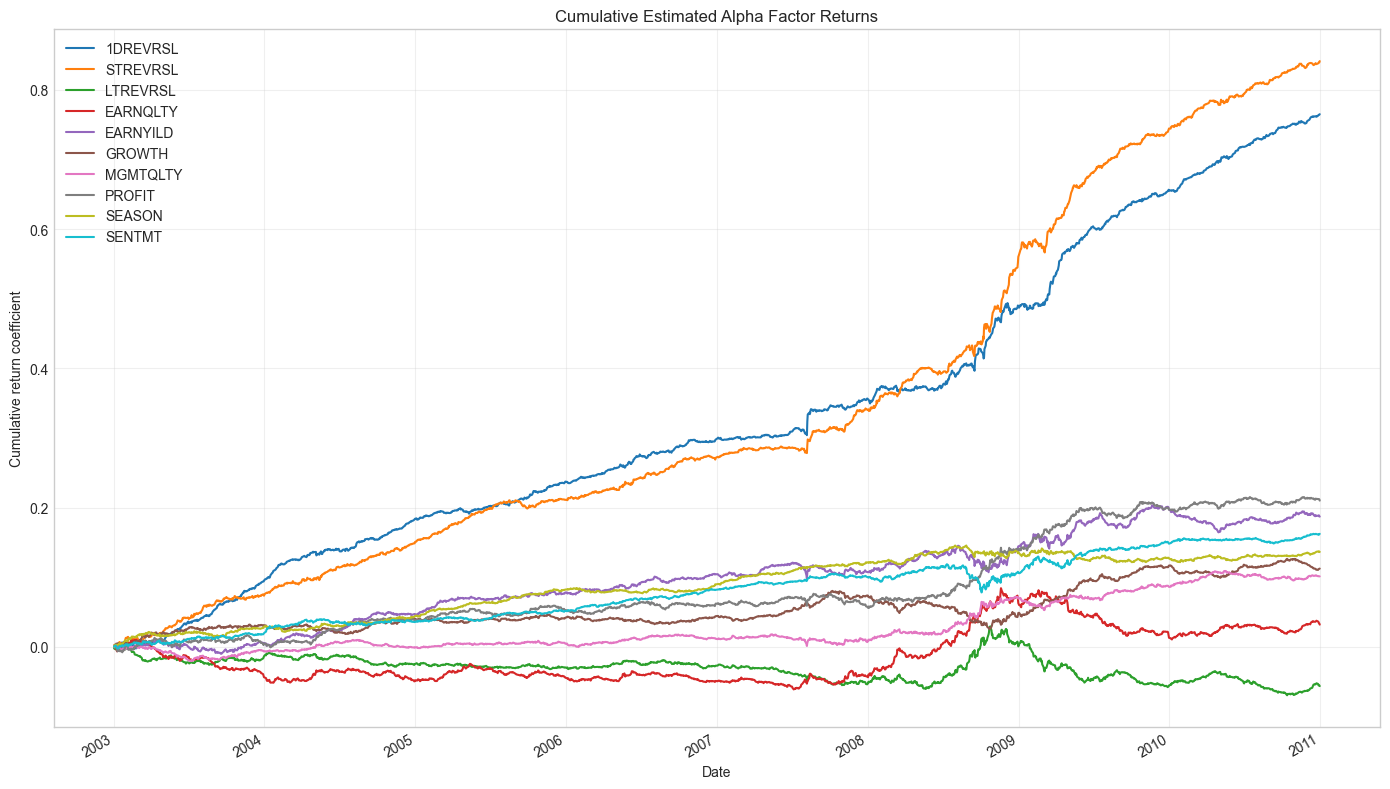

In [5]:
fig, ax = plt.subplots(figsize=(14, 8))
project.plot_cumulative_factor_returns(factor_returns, ax=ax)
plt.tight_layout()

In [6]:
best_factor = q1_summary.index[0]
worst_factor = q1_summary.index[-1]
best_sharpe = q1_summary.loc[best_factor, "Annualized Sharpe"]
worst_sharpe = q1_summary.loc[worst_factor, "Annualized Sharpe"]

print(f"Best alpha factor by Sharpe ratio: {best_factor} ({best_sharpe:.3f})")
print(f"Worst alpha factor by Sharpe ratio: {worst_factor} ({worst_sharpe:.3f})")
print()
print("Interpretation:")
print(
    f"The strongest in-sample evidence is for {best_factor}, because it has the highest annualized Sharpe ratio. "
    "This suggests predictive power before implementation costs. However, the estimated coefficient series is not itself "
    "a directly achievable strategy return. An investable strategy would need explicit holdings, risk controls, turnover "
    "constraints, liquidity filters, borrow assumptions, and transaction-cost modeling."
)

Best alpha factor by Sharpe ratio: 1DREVRSL (4.344)
Worst alpha factor by Sharpe ratio: LTREVRSL (-0.368)

Interpretation:
The strongest in-sample evidence is for 1DREVRSL, because it has the highest annualized Sharpe ratio. This suggests predictive power before implementation costs. However, the estimated coefficient series is not itself a directly achievable strategy return. An investable strategy would need explicit holdings, risk controls, turnover constraints, liquidity filters, borrow assumptions, and transaction-cost modeling.


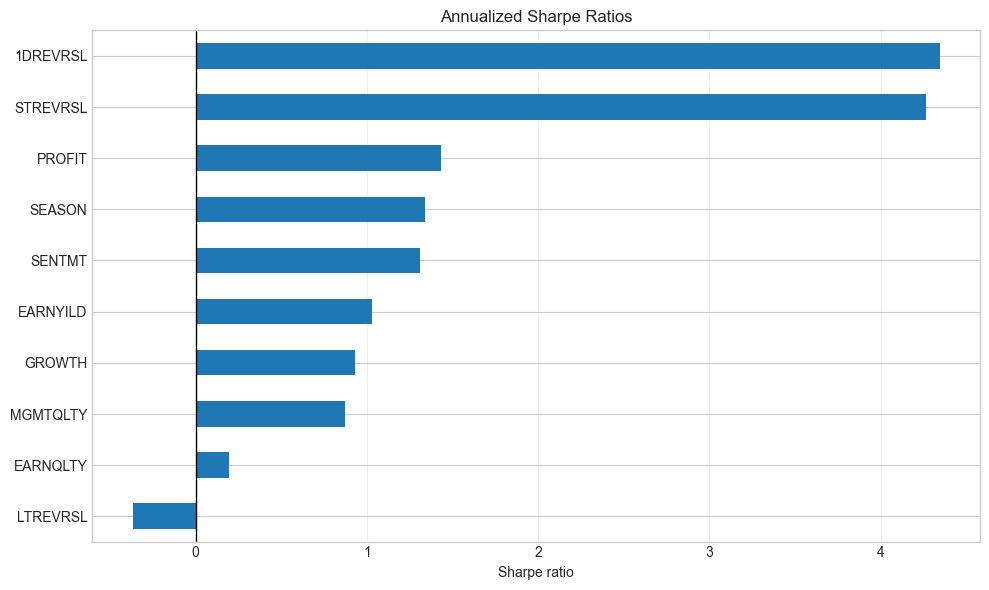

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
project.plot_sharpe_ratios(factor_returns, ax=ax)
plt.tight_layout()

## Problem 3.2 - Costless Portfolio Optimization

The first 2/3 of dates are used in-sample to estimate the combined-alpha coefficients. The last 1/3 of dates are used out-of-sample for portfolio optimization. The costless optimizer uses `scipy.optimize.fmin_l_bfgs_b` with the exact gradient, as requested in the prompt, while avoiding any `n x n` risk matrix.

In [8]:
in_sample_dates, out_of_sample_dates = project.split_dates()
alpha_coefficients = project.estimate_alpha_coefficients(factor_returns, in_sample_dates)

print(f"In-sample dates: {in_sample_dates[0]} to {in_sample_dates[-1]} ({len(in_sample_dates)} dates)")
print(f"Out-of-sample dates: {out_of_sample_dates[0]} to {out_of_sample_dates[-1]} ({len(out_of_sample_dates)} dates)")
alpha_coefficients.sort_values(ascending=False)

In-sample dates: 20030102 to 20080502 (1343 dates)
Out-of-sample dates: 20080505 to 20101231 (672 dates)


STREVRSL    0.000295
1DREVRSL    0.000277
SEASON      0.000099
EARNYILD    0.000094
SENTMT      0.000081
PROFIT      0.000052
GROWTH      0.000049
MGMTQLTY    0.000014
EARNQLTY   -0.000013
LTREVRSL   -0.000041
dtype: float64

In [9]:
# Use max_dates for a quick smoke test, then set it to None for the full out-of-sample run.
optimization_result = project.run_out_of_sample_optimization(
    factor_returns=factor_returns,
    kappa=1e-6,
    costs=CostParameters(),
    solver=None,
    max_dates=None,
)

profit = optimization_result.profit
profit_sharpe = (252 ** 0.5) * profit.mean() / profit.std(ddof=1)

print(f"Out-of-sample profit Sharpe ratio: {profit_sharpe:.3f}")
profit.describe()

Out-of-sample profit Sharpe ratio: 4.428


count         672.000000
mean      1095334.942248
std       3927145.222560
min     -16032019.979244
25%       -786221.938003
50%        869922.824563
75%       2926118.355534
max      22572077.858192
Name: profit, dtype: float64

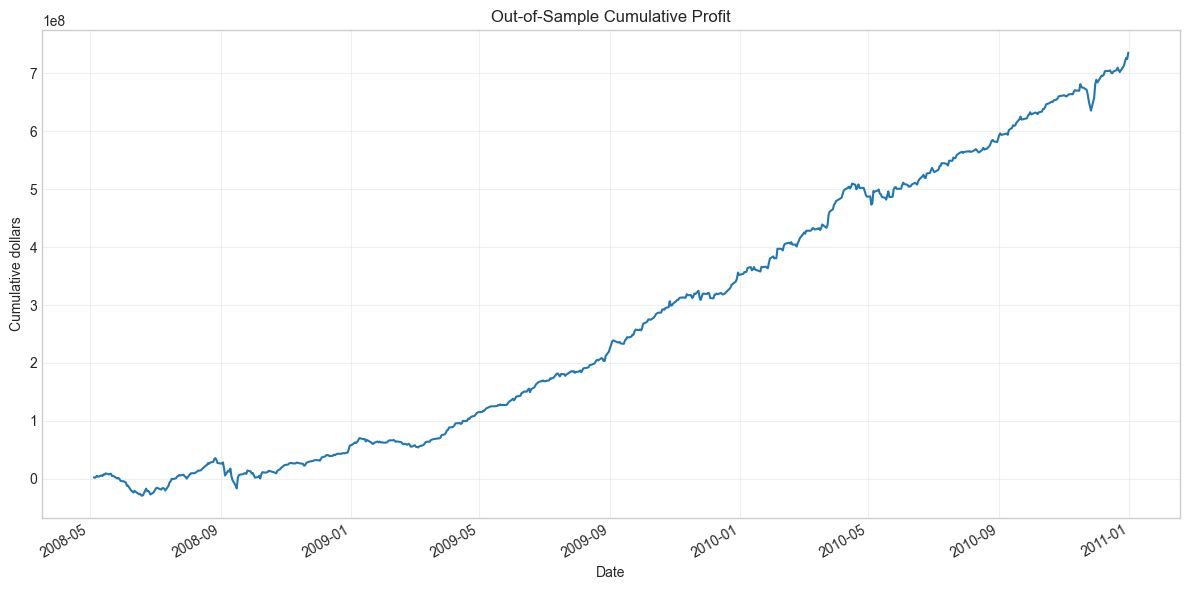

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
project.plot_cumulative_profit(profit, ax=ax)
plt.tight_layout()

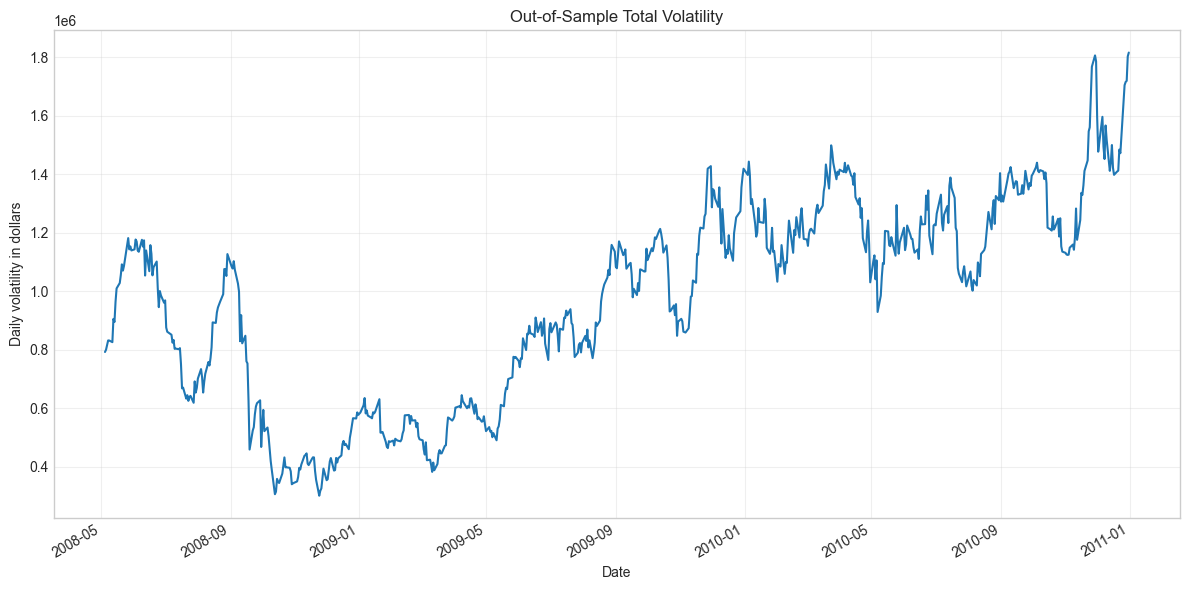

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
optimization_result.variance_decomposition["total_vol"].plot(ax=ax)
ax.set_title("Out-of-Sample Total Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Daily volatility in dollars")
ax.grid(True, alpha=0.3)
plt.tight_layout()

Variance-fraction sums: min=1.000000, max=1.000000


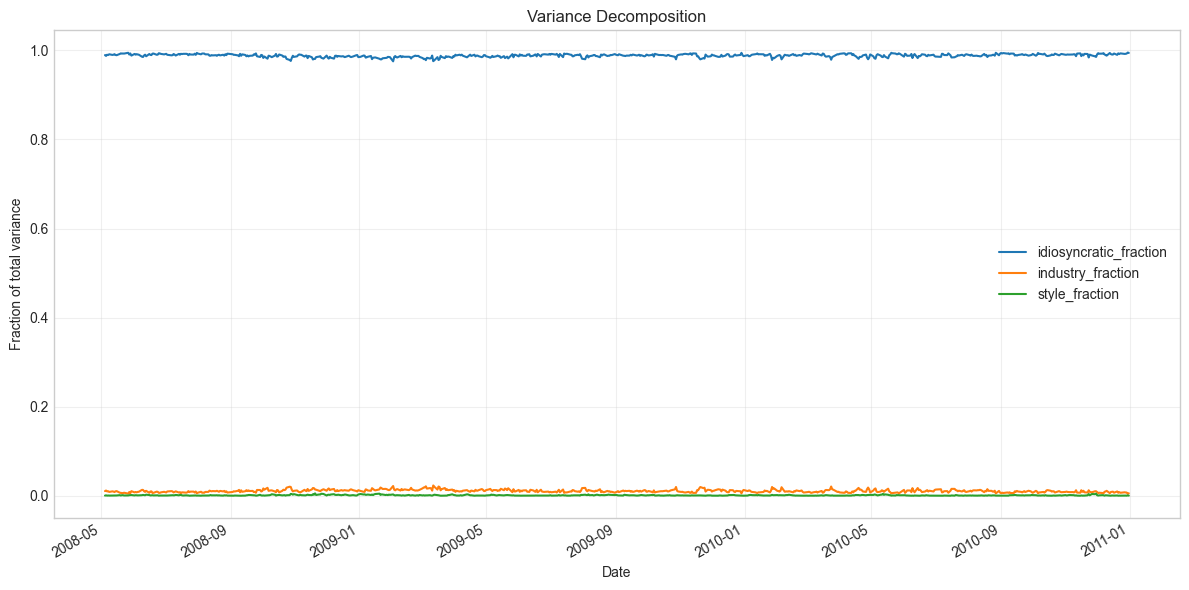

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
project.plot_variance_decomposition(optimization_result.variance_decomposition, ax=ax)
plt.tight_layout()

fraction_check = optimization_result.variance_decomposition[
    ["idiosyncratic_fraction", "industry_fraction", "style_fraction"]
].sum(axis=1)
print(f"Variance-fraction sums: min={fraction_check.min():.6f}, max={fraction_check.max():.6f}")


In [13]:
variance_summary = optimization_result.variance_decomposition[
    ["total_vol", "idiosyncratic_fraction", "industry_fraction", "style_fraction"]
].describe()
variance_summary


,total_vol,idiosyncratic_fraction,industry_fraction,style_fraction
count,672.000000,672.000000,672.000000,672.000000
mean,966602.990684,0.988497,0.010589,0.000914
std,339599.770781,0.003379,0.003062,0.000831
min,301842.565333,0.975396,0.004291,-0.000062
25%,635215.158811,0.986613,0.008443,0.000295
50%,1052621.481216,0.988945,0.010122,0.000698
75%,1216716.231662,0.990951,0.012357,0.001268
max,1815148.807283,0.995079,0.022993,0.005210


The variance decomposition is dominated by idiosyncratic risk. Industry and style fractions stay small throughout the out-of-sample period, and the fraction check above confirms that idiosyncratic, industry, and style variance add to total variance on every date.


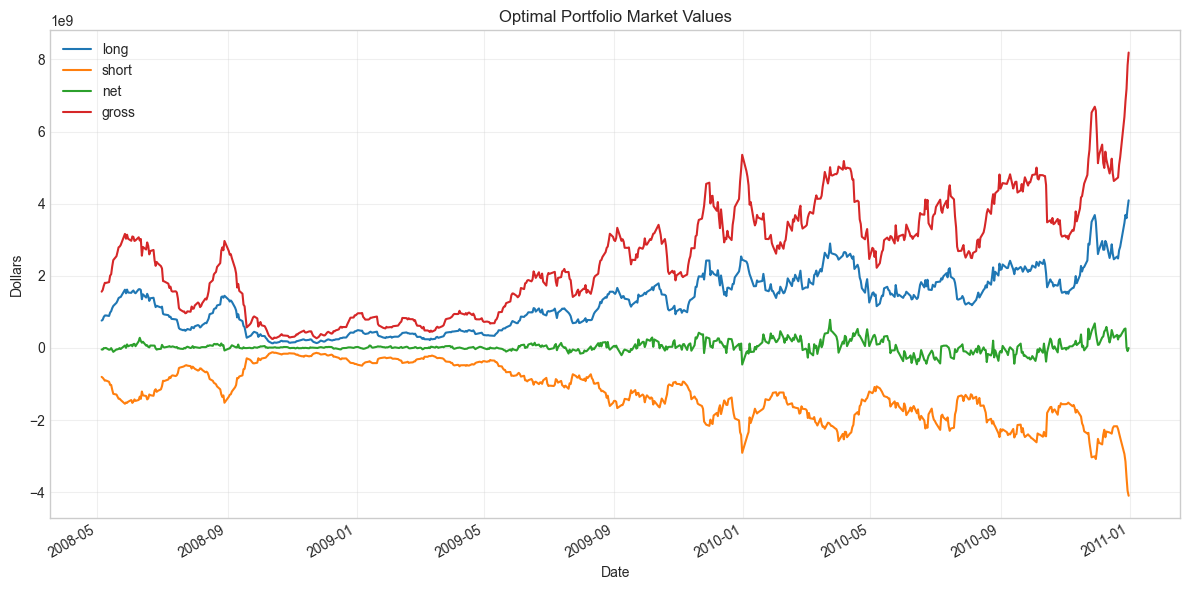

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
project.plot_exposures(optimization_result.exposures, ax=ax)
plt.tight_layout()

## Problem 3.2 Answer

The optimization uses the in-sample average factor returns as alpha coefficients, then applies the combined alpha only out-of-sample. For each out-of-sample date, the portfolio minimizes factor risk plus idiosyncratic risk minus expected return. The cumulative-profit plot and Sharpe ratio summarize the out-of-sample performance. The variance-decomposition plots show whether risk is mainly idiosyncratic, industry, or style-driven, and the exposure plot reports long, short, net, and gross dollar holdings.

## Problem 3.3 - Exact Costless Minimizer

For the costless objective, the first-order condition is `kappa * (X F X.T + D) h = alpha`. Therefore the exact minimizer is `h = (1 / kappa) * (X F X.T + D)^(-1) alpha`. The implementation uses the Woodbury identity, so it avoids forming the full `n x n` matrix.

In [15]:
# Exact minimizer from Problem 3.3.
exact_result = project.run_exact_out_of_sample_optimization(
    factor_returns=factor_returns,
    kappa=1e-6,
    max_dates=None,
)

exact_profit = exact_result.profit
exact_profit_sharpe = (252 ** 0.5) * exact_profit.mean() / exact_profit.std(ddof=1)
print(f"Exact-minimizer out-of-sample profit Sharpe ratio: {exact_profit_sharpe:.3f}")
exact_profit.describe()

Exact-minimizer out-of-sample profit Sharpe ratio: 4.427


count         672.000000
mean      1095228.673251
std       3927077.794052
min     -16038302.163930
25%       -784578.210101
50%        870546.455715
75%       2925355.531026
max      22570895.279074
Name: profit, dtype: float64

In [16]:
# Compare the numerical scipy solution to the exact formula.
profit_comparison = pd.DataFrame({
    "scipy_profit": optimization_result.profit,
    "exact_profit": exact_result.profit,
})
profit_comparison["difference"] = profit_comparison["scipy_profit"] - profit_comparison["exact_profit"]

print(f"Maximum absolute daily profit difference: {profit_comparison['difference'].abs().max():.6f}")
profit_comparison.describe()

Maximum absolute daily profit difference: 20233.591413


,scipy_profit,exact_profit,difference
count,672.000000,672.000000,672.000000
mean,1095334.942248,1095228.673251,106.268997
std,3927145.222560,3927077.794052,3890.475977
min,-16032019.979244,-16038302.163930,-18973.261400
25%,-786221.938003,-784578.210101,-2007.611016
50%,869922.824563,870546.455715,-27.594936
75%,2926118.355534,2925355.531026,2136.100150
max,22572077.858192,22570895.279074,20233.591413


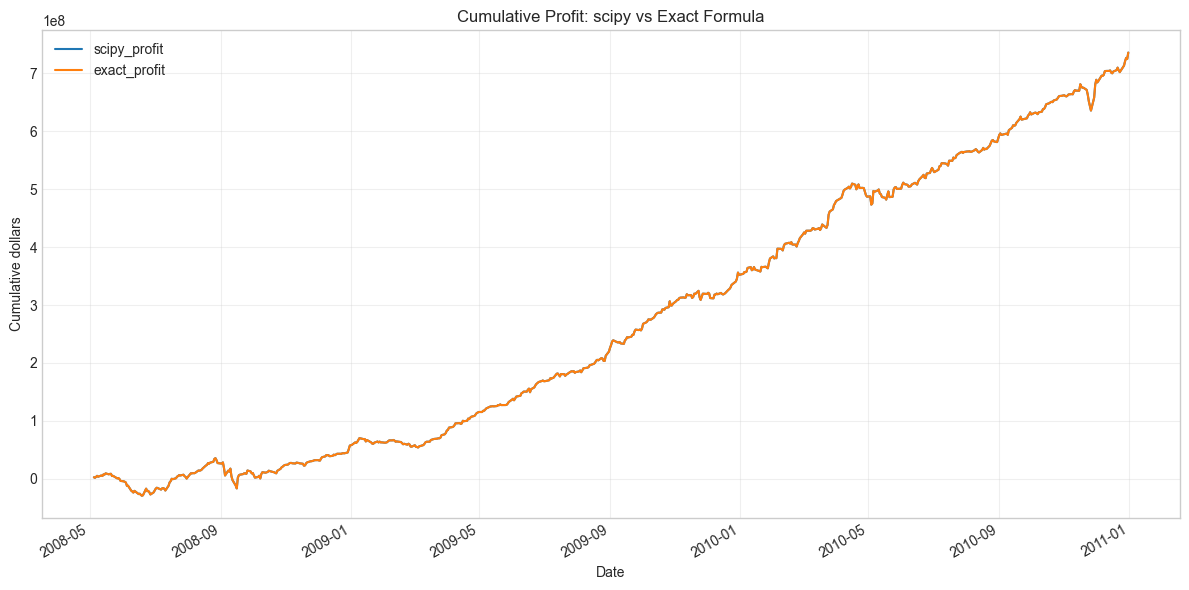

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
profit_comparison[["scipy_profit", "exact_profit"]].cumsum().plot(ax=ax)
ax.set_title("Cumulative Profit: scipy vs Exact Formula")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative dollars")
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Problem 3.3 Answer

The exact solution comes from setting the gradient equal to zero. The comparison table checks that the exact formula and the numerical `scipy` L-BFGS-B optimizer produce economically equivalent out-of-sample profit series, up to small numerical differences.

## Problem 3.4 - Cost-Aware Optimization

This section reruns the out-of-sample profit analysis with spread, market-impact, and borrow-cost terms included directly in a convex `cvxpy` objective. The assumptions are the ones from the prompt: 10 bps full spread, half-spread execution cost, square-root impact with `beta_1 = 1`, and 25 bps annualized borrow cost. Following the Module 10 formula, impact is modeled as `c_i |trade_i|^(3/2)` with `c_i = daily_vol_i / sqrt(volume_i)`. The data do not include stock prices or dollar ADV, so `CompositeVolume` is used as the available volume proxy and `TotalRisk` is converted from annualized percent to daily decimal volatility.

In [18]:
cost_parameters = CostParameters(
    spread_bps=10.0,
    borrow_bps_annual=25.0,
    impact_multiplier=1.0,
)

cost_aware_result = project.run_out_of_sample_optimization(
    factor_returns=factor_returns,
    kappa=1e-6,
    costs=cost_parameters,
    solver=None,
    max_dates=None,
    use_costless_initial_holdings=True,
)

cost_aware_pre_cost_profit = cost_aware_result.profit
cost_aware_net_profit = cost_aware_result.net_profit
cost_aware_pre_cost_sharpe = (252 ** 0.5) * cost_aware_pre_cost_profit.mean() / cost_aware_pre_cost_profit.std(ddof=1)
cost_aware_net_sharpe = (252 ** 0.5) * cost_aware_net_profit.mean() / cost_aware_net_profit.std(ddof=1)
print(f"Cost-aware pre-cost profit Sharpe ratio: {cost_aware_pre_cost_sharpe:.3f}")
print(f"Cost-aware net profit Sharpe ratio: {cost_aware_net_sharpe:.3f}")
cost_aware_net_profit.describe()

Cost-aware pre-cost profit Sharpe ratio: 0.162
Cost-aware net profit Sharpe ratio: -0.061


count      672.000000
mean       -17.830065
std       4670.296678
min     -50609.292168
25%       -937.542589
50%         55.101394
75%        918.330174
max      55702.629006
Name: net_profit, dtype: float64

In [19]:
cost_summary = pd.DataFrame({
    "pre_cost_profit": cost_aware_result.profit,
    "transaction_cost": cost_aware_result.transaction_cost,
    "net_profit": cost_aware_result.net_profit,
})
cost_summary.describe()

,pre_cost_profit,transaction_cost,net_profit
count,672.000000,672.000000,672.000000
mean,47.749244,65.579309,-17.830065
std,4668.832404,46.273532,4670.296678
min,-50571.567781,2.451241,-50609.292168
25%,-876.880114,27.765979,-937.542589
50%,115.698988,59.833823,55.101394
75%,1013.305144,93.442451,918.330174
max,55829.554793,346.229470,55702.629006


Note: the shared-axis plot can visually flatten the cost-aware series when costless holdings are much larger.


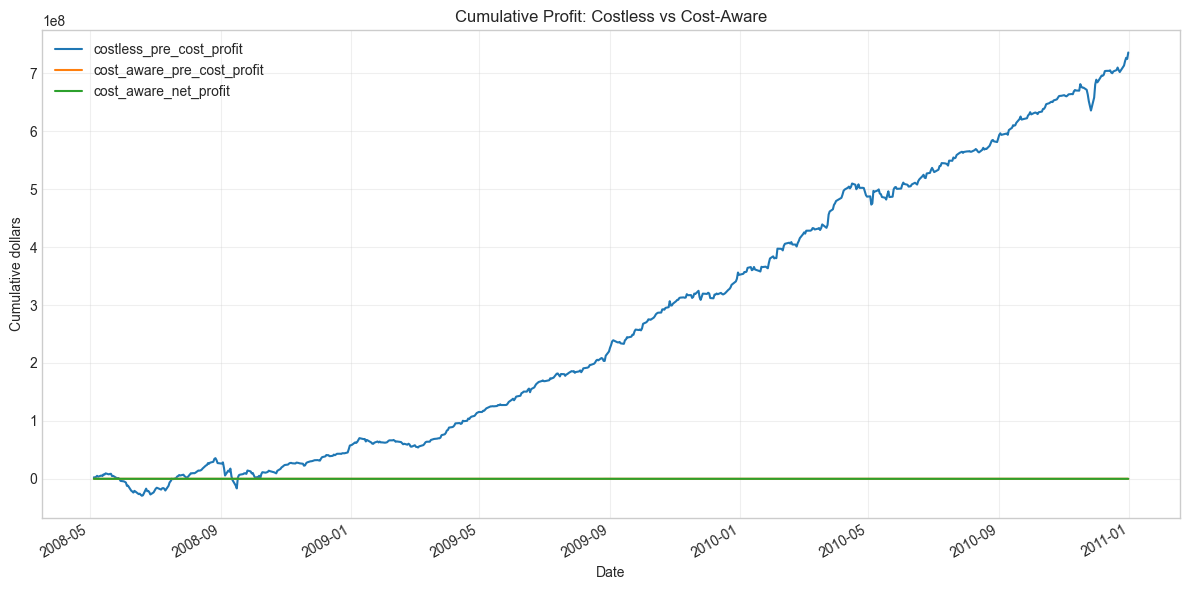

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
pd.DataFrame({
    "costless_pre_cost_profit": optimization_result.profit.cumsum(),
    "cost_aware_pre_cost_profit": cost_aware_result.profit.cumsum(),
    "cost_aware_net_profit": cost_aware_result.net_profit.cumsum(),
}).plot(ax=ax)
ax.set_title("Cumulative Profit: Costless vs Cost-Aware")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative dollars")
ax.grid(True, alpha=0.3)
plt.tight_layout()

print("Note: the shared-axis plot can visually flatten the cost-aware series when costless holdings are much larger.")


### Huge difference in scale is making cost-aware look like its almost constant, actual plot below -

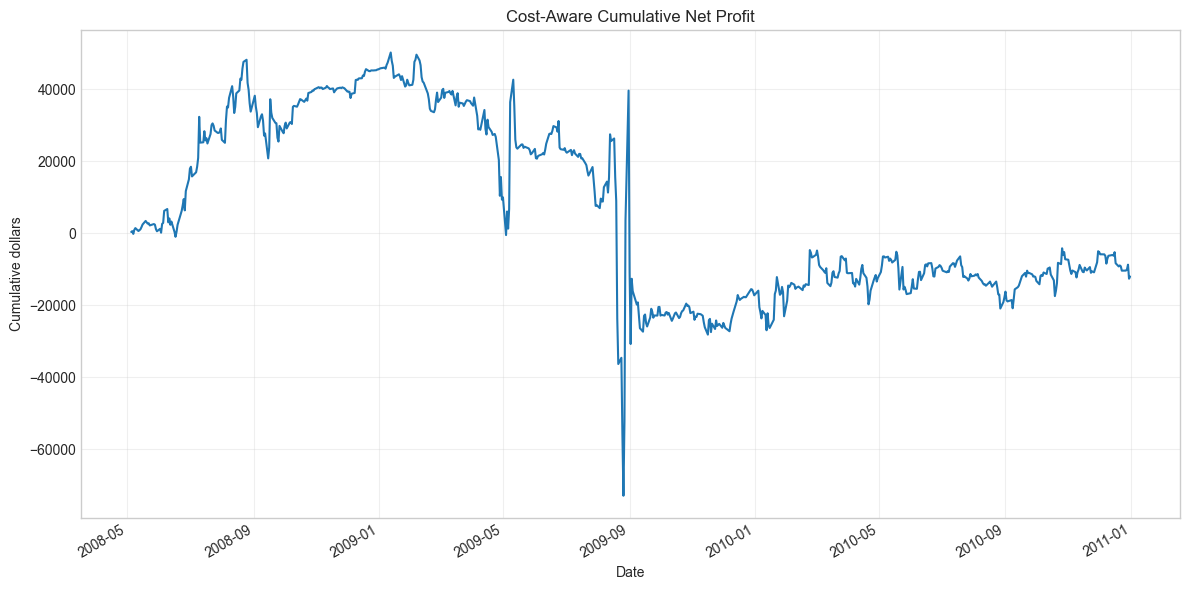

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
cost_aware_result.net_profit.cumsum().plot(ax=ax)
ax.set_title("Cost-Aware Cumulative Net Profit")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative dollars")
ax.grid(True, alpha=0.3)
plt.tight_layout()

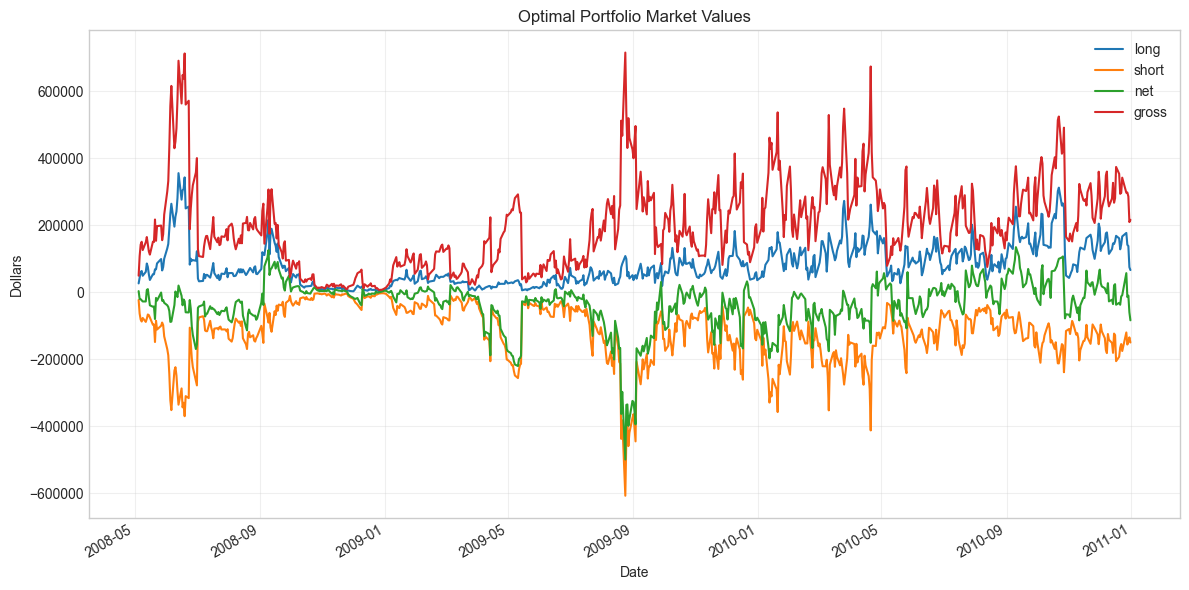

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
project.plot_exposures(cost_aware_result.exposures, ax=ax)
plt.tight_layout()

## Problem 3.4 Answer



Using cost-aware holdings, the pre-transaction-cost `h* · R` Sharpe ratio is 0.162. After subtracting the modeled spread, market impact, and borrow costs, the net profit Sharpe ratio is -0.061. So the assignment's pre-cost profit plot is much weaker than the costless optimizer, and the net result does not survive the stated implementation-cost assumptions.